In [1]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
import preprocessor as pp
from itertools import product

# importing model packages.

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

## Data Ingestion and Cleaning

In [3]:
forecaster = pp.Model_Preprocessor('Energy Forecaster')

# reading the datasets.

demand_df = forecaster.read_dataset(filename = 'totaldemand_nsw.csv', 
                                    col_names = {'DATETIME' :'datetime64[ns]', 'TOTALDEMAND' : 'float64'})
temp_df = forecaster.read_dataset(filename = 'temperature_nsw.csv',
                                  col_names = {'DATETIME': 'datetime64[ns]', 'TEMPERATURE' :'float64'})

cleaned_temp = forecaster.remove_duplicates(df = temp_df, col_name = 'datetime')
dates_df = forecaster.date_range(df = demand_df, date_col = 'datetime')

In [4]:
merged_df = pd.merge(
                pd.merge(dates_df, demand_df, left_on = 'ds', right_on = 'datetime', how = 'left'),
                cleaned_temp, left_on = 'ds', right_on = 'datetime', how = 'left'
)
merged_df.drop(['datetime_x', 'datetime_y'], axis = 1, inplace = True)

# Checking for missing values in the dataframe.

print("Null value checker:\n")
      
for col in merged_df.columns:
    print(f"{col}: {merged_df[col].isnull().sum()}")

# imputing missing values.

imputed_df = forecaster.fillin_missing_values(merged_df)

Null value checker:

ds: 0
season: 0
timeofday: 0
totaldemand: 1249
temperature: 1828


## Exploratory Data Analysis

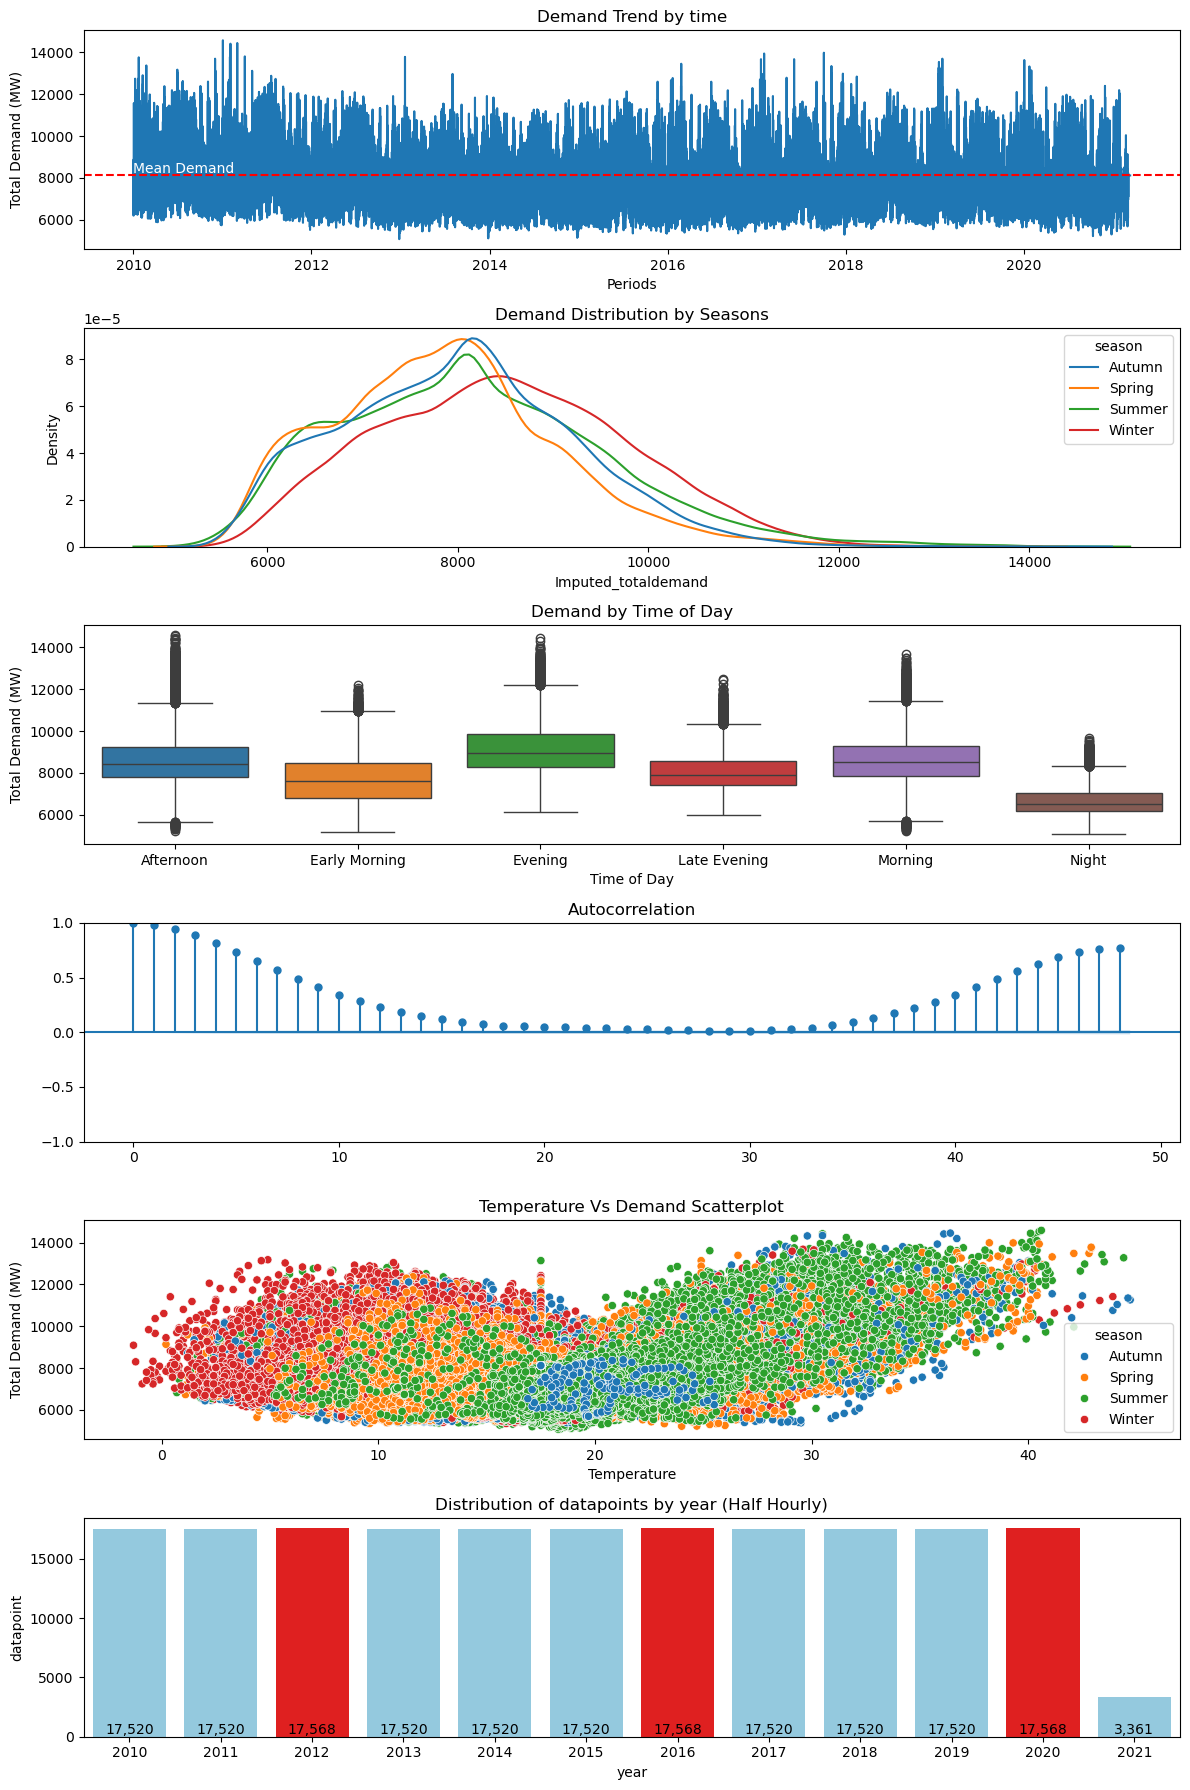

In [6]:
mean_demand = imputed_df['Imputed_totaldemand'].mean()

ts_df = imputed_df.set_index('ds')['Imputed_totaldemand']
ts_df.sort_index()

# Confirming that data is uniforminly distributed across all periods.

years = {year: imputed_df[imputed_df['ds'].dt.year == year].shape[0] for year in imputed_df['ds'].dt.year.unique()}
data = {'year' : [key for key in years.keys()], 'datapoint': [value for value in years.values()]}
data_df = pd.DataFrame(data = data)
leap_years = {2012,2016,2020}
colors = ['red' if year in leap_years else 'skyblue' for year in years.keys()]

fig, axes = plt.subplots(nrows = 6, ncols = 1, figsize = (12,18))

fig1 = sns.lineplot(data = imputed_df, x = 'ds', y = 'Imputed_totaldemand', ax = axes[0])
fig1.axhline(y = mean_demand, ls = '--', color = 'r')
fig1.annotate(text = 'Mean Demand', xy = (pd.Timestamp('2010-01-01'), 8250.0), color = 'w')
fig1.set_title("Demand Trend by time")
fig1.set_xlabel("Periods")
fig1.set_ylabel("Total Demand (MW)")

fig2 = sns.kdeplot(data = imputed_df, x = 'Imputed_totaldemand', hue = 'season', ax = axes[1])
fig2.set_title("Demand Distribution by Seasons")

fig3 = sns.boxplot(data = imputed_df, x = 'timeofday', y = 'Imputed_totaldemand', ax = axes[2], hue = 'timeofday')
fig3.set_title("Demand by Time of Day")
fig3.set_xlabel("Time of Day")
fig3.set_ylabel("Total Demand (MW)")

fig4 = plot_acf(ts_df, lags = 48, ax = axes[3])

fig5 = sns.scatterplot(data = imputed_df, x = 'Imputed_temperature', y = 'Imputed_totaldemand', hue = 'season', ax = axes[4])
fig5.set_title("Temperature Vs Demand Scatterplot")
fig5.set_xlabel("Temperature")
fig5.set_ylabel("Total Demand (MW)")

fig6 = sns.barplot(data = data_df, 
                   x = 'year',
                   y = 'datapoint',
                   palette = colors,
                   ax = axes[5],
                   hue = 'year',
                  legend = False)

for bar in fig6.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = 0
    label = f"{bar.get_height():,.0f}"
    fig6.text(x,y, label, ha = 'center', va = 'bottom')
    
fig6.set_title("Distribution of datapoints by year (Half Hourly)")
                
plt.tight_layout()
plt.show()

In [7]:
# Validating the above ACF plot through ADF diagnosis.

results = adfuller(ts_df)
print(f"ADF Statistic: {results[0]}")
print(f"P-value: {results[1]}\n")
print("Critical Values:\n")

for key, value in results[4].items():
    print(f"{key}: {value}")

print("\n\u2705 Data is Stationary" if results[1] < 0.05 else "\u2718 Data is Non-Stationary")

ADF Statistic: -29.047988318496262
P-value: 0.0

Critical Values:

1%: -3.4303833393777143
5%: -2.861554735562219
10%: -2.5667778432102666

✅ Data is Stationary


## Model Development - Cross Validation

In [ ]:
model_df = forecaster.resample_data(df = imputed_df, mapping_df = dates_df)
train_df, test_df = model_df[model_df['ds'].dt.year <= 2020], model_df[model_df['ds'].dt.year > 2020]

params = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1],
    'seasonality_prior_scale': [0.1, 1.0, 5.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9],
    'n_changepoints':[5, 10, 15, 20]
}

all_params = [
    dict(zip(params.keys(), values))
    for values in product(*params.values())
]

best_model_params = {}

for param in all_params:
    base_rmse = float('inf')
    base_mape = float('inf')
    base_mae = float('inf')
    
    try:
        model = Prophet(
            changepoint_prior_scale = param['changepoint_prior_scale'],
            seasonality_prior_scale = param['seasonality_prior_scale'],
            seasonality_mode = param['seasonality_mode'],
            changepoint_range = param['changepoint_range'],
            n_changepoints = param['n_changepoints'],
            yearly_seasonality = True,
            daily_seasonality = True,
            weekly_seasonality = True
        )
        model.add_country_holidays(country_name = 'AU')

        cols_for_regressor = [col for col in train_df.columns if (model_df[col].dtype != 'datetime64[ns]') and (col != 'y')]
        for col in cols_for_regressor:
            model.add_regressor(col, prior_scale = 0.5, mode = 'multiplicative')
    
        model.fit(train_df)
    
        cv = cross_validation(
            model = model,
            initial = '1865 days',
            period = '90 days',
            horizon = '90 days'
        )
        
        cv_perf = performance_metrics(cv)
        rmse, mape, mae = cv_perf['rmse'].mean(), cv_perf['mape'].mean(), cv_perf['mae'].mean()

        if (mape < base_mape) and (rmse < base_rmse) and (mae < base_mae * 1.05):
            base_mape = mape
            base_rmse = rmse
            base_mae = mae
            
            best_model_params['Final_Params'] = {
                'changepoint_prior_scale':  param['changepoint_prior_scale'],
                'seasonality_prior_scale': param['seasonality_prior_scale'],
                'seasonality_mode': param['seasonality_mode'],
                'changepoint_range': param['changepoint_range'],
                'n_changepoints': param['n_changepoints'],
                'mape': round(base_mape,2),
                'rmse': round(base_rmse,2),
                'mae': round(base_mae,2)
            }

    except Exception as e:
        print(f"Training Failed: params = {param}, error = {e}.")
        continue

21:26:48 - cmdstanpy - INFO - Chain [1] start processing
21:26:53 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/23 [00:00<?, ?it/s]

21:26:54 - cmdstanpy - INFO - Chain [1] start processing
21:26:57 - cmdstanpy - INFO - Chain [1] done processing
21:26:58 - cmdstanpy - INFO - Chain [1] start processing
21:27:01 - cmdstanpy - INFO - Chain [1] done processing
21:27:02 - cmdstanpy - INFO - Chain [1] start processing
21:27:07 - cmdstanpy - INFO - Chain [1] done processing
21:27:08 - cmdstanpy - INFO - Chain [1] start processing
21:27:13 - cmdstanpy - INFO - Chain [1] done processing
21:27:15 - cmdstanpy - INFO - Chain [1] start processing
21:27:16 - cmdstanpy - INFO - Chain [1] done processing
21:27:17 - cmdstanpy - INFO - Chain [1] start processing
21:27:19 - cmdstanpy - INFO - Chain [1] done processing
21:27:21 - cmdstanpy - INFO - Chain [1] start processing
21:27:23 - cmdstanpy - INFO - Chain [1] done processing
21:27:25 - cmdstanpy - INFO - Chain [1] start processing
21:27:26 - cmdstanpy - INFO - Chain [1] done processing
21:27:28 - cmdstanpy - INFO - Chain [1] start processing
21:27:31 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/23 [00:00<?, ?it/s]

21:29:01 - cmdstanpy - INFO - Chain [1] start processing
21:29:05 - cmdstanpy - INFO - Chain [1] done processing
21:29:06 - cmdstanpy - INFO - Chain [1] start processing
21:29:11 - cmdstanpy - INFO - Chain [1] done processing
21:29:12 - cmdstanpy - INFO - Chain [1] start processing
21:29:15 - cmdstanpy - INFO - Chain [1] done processing
21:29:16 - cmdstanpy - INFO - Chain [1] start processing
21:29:18 - cmdstanpy - INFO - Chain [1] done processing
21:29:20 - cmdstanpy - INFO - Chain [1] start processing
21:29:23 - cmdstanpy - INFO - Chain [1] done processing
21:29:24 - cmdstanpy - INFO - Chain [1] start processing
21:29:27 - cmdstanpy - INFO - Chain [1] done processing
21:29:28 - cmdstanpy - INFO - Chain [1] start processing
21:29:34 - cmdstanpy - INFO - Chain [1] done processing
21:29:36 - cmdstanpy - INFO - Chain [1] start processing
21:29:40 - cmdstanpy - INFO - Chain [1] done processing
21:29:41 - cmdstanpy - INFO - Chain [1] start processing
21:29:46 - cmdstanpy - INFO - Chain [1]

...

07:58:33 - cmdstanpy - INFO - Chain [1] start processing
07:58:38 - cmdstanpy - INFO - Chain [1] done processing
07:58:40 - cmdstanpy - INFO - Chain [1] start processing
07:58:43 - cmdstanpy - INFO - Chain [1] done processing
07:58:45 - cmdstanpy - INFO - Chain [1] start processing
07:58:48 - cmdstanpy - INFO - Chain [1] done processing
07:58:49 - cmdstanpy - INFO - Chain [1] start processing
07:58:55 - cmdstanpy - INFO - Chain [1] done processing
07:58:57 - cmdstanpy - INFO - Chain [1] start processing
07:59:01 - cmdstanpy - INFO - Chain [1] done processing
07:59:02 - cmdstanpy - INFO - Chain [1] start processing
07:59:07 - cmdstanpy - INFO - Chain [1] done processing
07:59:09 - cmdstanpy - INFO - Chain [1] start processing
07:59:12 - cmdstanpy - INFO - Chain [1] done processing
07:59:14 - cmdstanpy - INFO - Chain [1] start processing
07:59:19 - cmdstanpy - INFO - Chain [1] done processing
07:59:20 - cmdstanpy - INFO - Chain [1] start processing
07:59:23 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/23 [00:00<?, ?it/s]

08:01:02 - cmdstanpy - INFO - Chain [1] start processing
08:01:09 - cmdstanpy - INFO - Chain [1] done processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:21 - cmdstanpy - INFO - Chain [1] done processing
08:01:22 - cmdstanpy - INFO - Chain [1] start processing
08:01:30 - cmdstanpy - INFO - Chain [1] done processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:40 - cmdstanpy - INFO - Chain [1] done processing
08:01:41 - cmdstanpy - INFO - Chain [1] start processing
08:02:08 - cmdstanpy - INFO - Chain [1] done processing
08:02:10 - cmdstanpy - INFO - Chain [1] start processing
08:18:24 - cmdstanpy - INFO - Chain [1] done processing
08:18:25 - cmdstanpy - INFO - Chain [1] start processing
08:24:36 - cmdstanpy - INFO - Chain [1] done processing
08:24:37 - cmdstanpy - INFO - Chain [1] start processing
08:25:24 - cmdstanpy - INFO - Chain [1] done processing
08:25:26 - cmdstanpy - INFO - Chain [1] start processing
08:54:27 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/23 [00:00<?, ?it/s]

16:08:39 - cmdstanpy - INFO - Chain [1] start processing
16:25:50 - cmdstanpy - INFO - Chain [1] done processing
16:25:51 - cmdstanpy - INFO - Chain [1] start processing
